In [294]:
%matplotlib inline 
import matplotlib.pyplot as plt
import IPython.display as ipd

import os
os.chdir('/engram/nklab/pf2477/multimodal_encoder/')

import sys
print(sys.executable)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF


import nibabel as nib
from nilearn import datasets, plotting


/engram/nklab/pf2477/multimodal_encoder/.pixi/envs/default/bin/python


In [295]:
from cneuro_dataset.cneuro_data import algonauts_dataset
from args import get_args_parser
parser = get_args_parser()
args = parser.parse_args(args=[])
print(args)
root_data_dir = '/engram/nklab/datasets/'

CACHE_DIR = "/engram/nklab/models/hf_cache"
MEAN = [0.485, 0.456, 0.406]  # Mean used for normalization
STD = [0.229, 0.224, 0.225]  # Standard deviation used for normalization
RATIO=2
VIDEO_SIZE = [80 * RATIO, 192 * RATIO]  # Size of the video frames

attn_map_path = "attn_maps/1/04-07-2026-16-09/figures.h5py"
sample_id = 368 # 385 347 368
# attn_map_path = "ckpt/1/04-18-2026-01-08/best.pt"
modality_specs = {
    "video": (0, 3216),   # dino: 16 frames * 201 tokens/frame
    "audio": (3216, 4716),  # whisper: 1500 tokens
    "text": (4716, 5228),   # llama: 512 tokens
}

modality_attention_config = {
    "video": {"attention_summary": "network", "network_name": "Vis", "parcel_id": 1},
    "audio": {"attention_summary": "network", "network_name": "Default", "parcel_id": 1},
    "text": {"attention_summary": "network", "network_name": "Limbic", "parcel_id": 1},
}

color_map = 'viridis' #'plasma' # 'viridis' 

from models.multimodel_backbone import BACKBONE_LIST
args.test_splits = ["figures"]
args.backbone_list = BACKBONE_LIST
args.video_backbone = "dino"
args.audio_backbone = "whisper"
args.text_backbone = "llama"

args.readout_res = "parcels"
test_dataset = algonauts_dataset(args, include_splits=args.test_splits)
args.valid_voxel_mask = test_dataset.valid_voxel_mask if args.readout_res == "voxels" else None
args.masked_parcellation = test_dataset.masked_parcellation if args.readout_res == "voxels" else None

Namespace(ckpt_root='./ckpt', seed=42, epochs=15, batch_size=8, num_workers=2, pipeline_sanity_check=False, sanity_batches=2, lr=0.0001, weight_decay=0.0001, step_size=100, step_size_gamma=0.1, max_grad_norm=0.1, l2_reg=0.0, train_splits='friends-train-default', val_splits='friends-test-default', test_splits='movie10-ood-default', use_wandb=False, wandb_project='multimodal-encoder', wandb_run_name=None, resume=None, eval_only=False, save_checkpoints=False, save_test_predictions=False, save_test_movie_breakdown=False, save_test_causal_intervention=False, save_encoding_acc=True, subj=1, target_subj=1, readout_res='parcels', num_queries=1000, num_frames=16, num_parcels=1000, num_voxels=122721, modality=['video', 'audio', 'text'], video_backbone='metaclip', audio_backbone='whisper', text_backbone='metaclip', enc_layers=0, dec_layers=1, dim_feedforward=512, hidden_dim=256, dropout=0.1, nheads=8, pre_norm=1, enc_output_layer=-1, modality_dropout=0.2, attn_maps=False, attn_write_mode='batch',

## Stimuli

In [296]:

media_data, fmri_data = test_dataset[sample_id] # 4863 total
video = media_data["video"]
audio = media_data["audio"]
text = media_data["text"]
print(media_data['split'], media_data['ind']) 

figures01 368


In [297]:
from models.multimodel_backbone import ProcessorWrapper

processor_wrapper = ProcessorWrapper(
    modality="text",
    backbone=args.text_backbone,
    cache_dir=CACHE_DIR,
)
tokenizer = processor_wrapper.processor
tokens = text['input_ids'].squeeze().tolist()
# recovered_text = tokenizer.decode(text['input_ids'].squeeze().tolist())
valid_tokens = [token for token, mask in zip(tokens, text['attention_mask'].squeeze().tolist()) if mask]
print(tokenizer.convert_ids_to_tokens(valid_tokens))

['<|begin_of_text|>', 'How', "'d", 'Ġthat', 'Ġfeel', 'Ġin', 'Ġthere', ',', 'ĠPaul', '?', 'ĠYou', 'Ġthink', 'Ġyou', 'Ġenlightened', 'Ġthe', 'Ġadministrator', '?', 'ĠHmm', '?', 'ĠNo', ',', 'Ġhe', 'Ġdidn', "'t", 'Ġlook', 'Ġenlightened', 'Ġto', 'Ġme', '.', 'ĠLook', 'ed', 'Ġenlightened', 'Ġto', 'Ġyou', ',', 'ĠSam', '?', 'ĠNot', 'Ġparticularly', '.', 'ĠAnd', 'Ġjust', 'Ġso', 'Ġyou', 'Ġknow', ',', 'Ġhe', "'s", 'Ġnot', 'Ġwrong', 'Ġabout', 'Ġwhat', 'Ġhe', 'Ġsaid', 'Ġin', 'Ġthere', '.', 'ĠYou', 'Ġknow', 'Ġthat', ',', 'Ġright', '?', 'ĠBecause', 'Ġnow', 'Ġthat', 'Ġthey', 'Ġcan', 'Ġget', 'Ġup', 'Ġthere', ',', 'Ġa', 'Ġbomb', 'Ġwill', 'Ġfollow', '.', 'ĠThat', "'s", 'Ġwhat', 'Ġhappens', 'Ġto', 'Ġall', 'Ġour', 'Ġgood', 'Ġideas', '.', 'ĠI', 'Ġimagine', 'Ġtheirs', 'Ġtoo', '.', 'ĠWhere', '.', 'ĠWhere', "'s", 'Ġthe', 'Ġmachine', '?', 'ĠAny', 'Ġday', 'Ġnow', ',', 'ĠMister', 'ĠHarrison', '.', 'ĠAny', 'Ġday', 'Ġnow', '.', 'ĠYes', ',', 'Ġsir', '.']


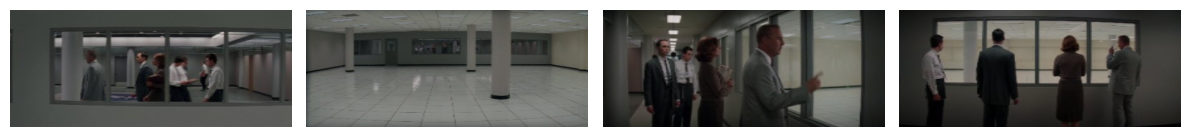

In [298]:

def denormalize(tensor, mean, std):
    """Denormalizes a tensor image."""
    # Create an inverse transform
    inv_normalize = transforms.Normalize(
        mean=[-m / s for m, s in zip(mean, std)],
        std=[1 / s for s in std]
    )

    # Apply the inverse transform
    return inv_normalize(tensor)

frames = video['pixel_values'] # torch.Size([16, 3, 224, 224])

# # Create a figure with a 5x4 grid of subplots
# # Example: Plot random data in each subplot
# fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(8, 8))  # Adjust figure size as needed
# for i in range(4):
#     for j in range(4):
#         f = i*4 + j
#         img = denormalize(frames[f], MEAN, STD)
#         img = TF.resize(img, [80, 192])   # pick the size you want
#         axes[i, j].imshow(img.permute(1, 2, 0))  # Example random plot
#         axes[i, j].axis('off')

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))
for i in range(4):
    f = i * 4 + i
    img = denormalize(frames[f], MEAN, STD)
    img = TF.resize(img, VIDEO_SIZE)   # pick the size you want
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].axis("off")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

## Yeo 7 Networks

In [299]:

def as_str(label):
    return label.decode("utf-8") if isinstance(label, bytes) else str(label)


def parse_schaefer_label(label):
    label = as_str(label)
    parts = label.split("_")
    return {
        "schaefer_name": label,
        "hemi": parts[1],
        "network": parts[2],
        "region": "_".join(parts[3:-1]),
        "parcel_index_in_lut": int(parts[-1]),
    }


def load_schaefer_labels(n_rois=1000, yeo_networks=17, resolution_mm=2):
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=yeo_networks,
        resolution_mm=resolution_mm,
    )
    raw_labels = [as_str(label) for label in atlas.labels if as_str(label) != "Background"]

    network_order = []
    rows = []
    for parcel_id, label in enumerate(raw_labels, start=1):
        parsed = parse_schaefer_label(label)
        if parsed["network"] not in network_order:
            network_order.append(parsed["network"])
        rows.append({"parcel_id": parcel_id, **parsed})

    return pd.DataFrame(rows), network_order


labels_df, schaefer_labels = load_schaefer_labels(yeo_networks=7)
print(schaefer_labels)


[fetch_atlas_schaefer_2018] Dataset found in /home/pf2477/nilearn_data/schaefer_2018
['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']


## Attention Map

In [300]:
import h5py
from IPython.display import HTML, display

to_np = lambda x: x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)

def _normalize01(values):
    values = np.asarray(values, dtype=np.float32)
    return (values - values.min()) / (values.max() - values.min())

sample_split = str(media_data["split"])
sample_ind = int(media_data["ind"])

with h5py.File(attn_map_path, "r") as h5f:
    attn_ds = h5f["attn_maps"]
    split_values = np.asarray([s.decode("utf-8") if isinstance(s, bytes) else str(s) for s in h5f["split"][:]])
    ind_values = np.asarray(h5f["ind"][:], dtype=np.int32)
    h5_sample_idx = int(np.flatnonzero((split_values == sample_split) & (ind_values == sample_ind))[0])
    attn_sample = np.asarray(attn_ds[h5_sample_idx], dtype=np.float32)

attn_qt = attn_sample.mean(axis=0)  # [Q, T]

def get_token_attention(attn_qt, attention_summary="network", network_name="Vis", parcel_id=1):
    if attention_summary == "network":
        query_indices = labels_df.index[labels_df["network"] == network_name].to_numpy()
        query_label = f"{network_name} network"
    elif attention_summary == "parcel":
        query_indices = np.asarray([parcel_id - 1])
        query_label = labels_df.loc[parcel_id - 1, "schaefer_name"]
    else:
        query_indices = np.arange(attn_qt.shape[0])
        query_label = "all parcels"

    token_attn = attn_qt[query_indices].mean(axis=0)
    token_attn = token_attn / np.clip(token_attn.sum(), 1e-12, None)

    sample_modality_attn = pd.DataFrame([
        {
            "modality": modality,
            "raw_attention_mass": float(token_attn[start:end].sum()),
            "token_count": int(end - start),
            "token_count_normalized": float(token_attn[start:end].sum()) / int(end - start),
        }
        for modality, (start, end) in modality_specs.items()
    ])
    sample_modality_attn["normalized_fraction"] = (
        sample_modality_attn["token_count_normalized"]
        / sample_modality_attn["token_count_normalized"].sum()
    )
    return token_attn, sample_modality_attn, query_label, query_indices

def set_modality_attention(modality, attention_summary="network", network_name="Vis", parcel_id=1):
    token_attn, summary_df, query_label, query_indices = get_token_attention(
        attn_qt,
        attention_summary=attention_summary,
        network_name=network_name,
        parcel_id=parcel_id,
    )
    modality_attention[modality] = {
        "token_attn": token_attn,
        "summary": summary_df,
        "query_label": query_label,
        "query_indices": query_indices,
        "config": {
            "attention_summary": attention_summary,
            "network_name": network_name,
            "parcel_id": parcel_id,
        },
    }
    return modality_attention[modality]


modality_attention = {}
for modality, config in modality_attention_config.items():
    set_modality_attention(modality, **config)

sample_modality_attn = pd.concat(
    [
        result["summary"].assign(attention_for=modality, query_label=result["query_label"])
        for modality, result in modality_attention.items()
    ],
    ignore_index=True,
)

print(
    f"Loaded sample_id={sample_id} from HDF5 row {h5_sample_idx}: "
    f"split={sample_split}, ind={sample_ind}, attn_sample_shape={attn_sample.shape}"
)
display(sample_modality_attn)

Loaded sample_id=368 from HDF5 row 368: split=figures01, ind=368, attn_sample_shape=(1, 1000, 5228)


,modality,raw_attention_mass,token_count,token_count_normalized,normalized_fraction,attention_for,query_label
0,video,0.520204,3216,0.000162,0.305222,video,Vis network
1,audio,0.442221,1500,0.000295,0.556297,video,Vis network
2,text,0.037575,512,0.000073,0.138481,video,Vis network
3,video,0.357146,3216,0.000111,0.178517,audio,Default network
4,audio,0.578752,1500,0.000386,0.620228,audio,Default network
5,text,0.064101,512,0.000125,0.201255,audio,Default network
6,video,0.439408,3216,0.000137,0.220425,text,Limbic network
7,audio,0.475475,1500,0.000317,0.511381,text,Limbic network
8,text,0.085116,512,0.000166,0.268194,text,Limbic network


Video attention: Vis network, shape: (3216,), num_frames: 16, tokens_per_frame: 201


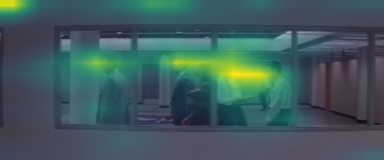

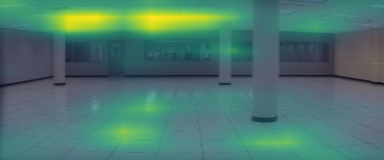

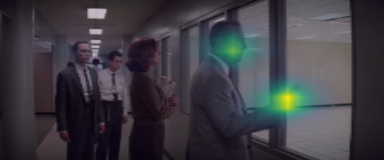

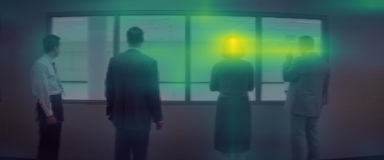

In [301]:
# Video: DINO has 201 tokens per frame: CLS + 4 register tokens + 14x14 spatial patches.
from matplotlib.colors import ListedColormap
from pathlib import Path
from PIL import Image as PILImage
from scipy.ndimage import gaussian_filter

def get_alpha_cmap(cmap):
    cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    alpha_cmap = cmap(np.arange(cmap.N))
    alpha_cmap[:, -1] = np.linspace(0, 1, cmap.N)
    return ListedColormap(alpha_cmap)


def process_video_heatmap(A, image_size, scale=1e5, sigma=0.75, percentiles=(1, 99)):
    A = A / (A.sum() + 1e-8)
    # A = np.log1p(A * scale)
    A = gaussian_filter(A, sigma=sigma)
    A = torch.tensor(A)[None, None]
    A = torch.nn.functional.interpolate(A, size=image_size, mode="bilinear", align_corners=False).squeeze().numpy()
    low, high = np.percentile(A, percentiles)
    A = np.clip(A, low, high)
    return (A - low) / (high - low + 1e-8)


video_token_attn = modality_attention["video"]["token_attn"]
video_query_label = modality_attention["video"]["query_label"]
video_start, video_end = modality_specs["video"]
video_attn = video_token_attn[video_start:video_end]
num_frames = int(frames.shape[0])
tokens_per_frame = int(video_attn.size // num_frames)
print(f"Video attention: {video_query_label}, shape: {video_attn.shape}, num_frames: {num_frames}, tokens_per_frame: {tokens_per_frame}")
grid_size = 14
spatial_tokens = grid_size * grid_size
non_spatial_tokens = tokens_per_frame - spatial_tokens
video_frame_tokens = video_attn.reshape(num_frames, tokens_per_frame)
video_patch_attn = video_frame_tokens[:, non_spatial_tokens:].reshape(num_frames, grid_size, grid_size)
alpha_cmap = get_alpha_cmap(color_map)

frame_ids = np.linspace(0, num_frames - 1, min(4, num_frames)).round().astype(int)
for frame_idx in frame_ids:
# for frame_idx in range(num_frames):
    img = denormalize(frames[frame_idx], MEAN, STD).clamp(0, 1)
    img = TF.resize(img, VIDEO_SIZE)
    heat = process_video_heatmap(video_patch_attn[frame_idx], VIDEO_SIZE, scale=1e5, sigma=0.75, percentiles=(0, 100))
    colored_attention = alpha_cmap(heat)
    base = img.permute(1, 2, 0).numpy()
    alpha = (0.1 + 0.9 * colored_attention[..., 3:4]) * (heat > 0)[..., None]
    # alpha = 0
    frame_vis = base * (1 - alpha) + colored_attention[..., :3] * alpha
    frame_img = PILImage.fromarray((255 * np.clip(frame_vis, 0, 1)).astype(np.uint8))
    display(frame_img)

    out_path = Path(f"./notebooks/figures/attn/video_{sample_id}_{frame_idx}.png")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    frame_img.save(out_path)




mel.shape=(80, 2237), audio_attn.shape=(1500,), att_mel.shape=(2237,), cropped_to_frame=2237


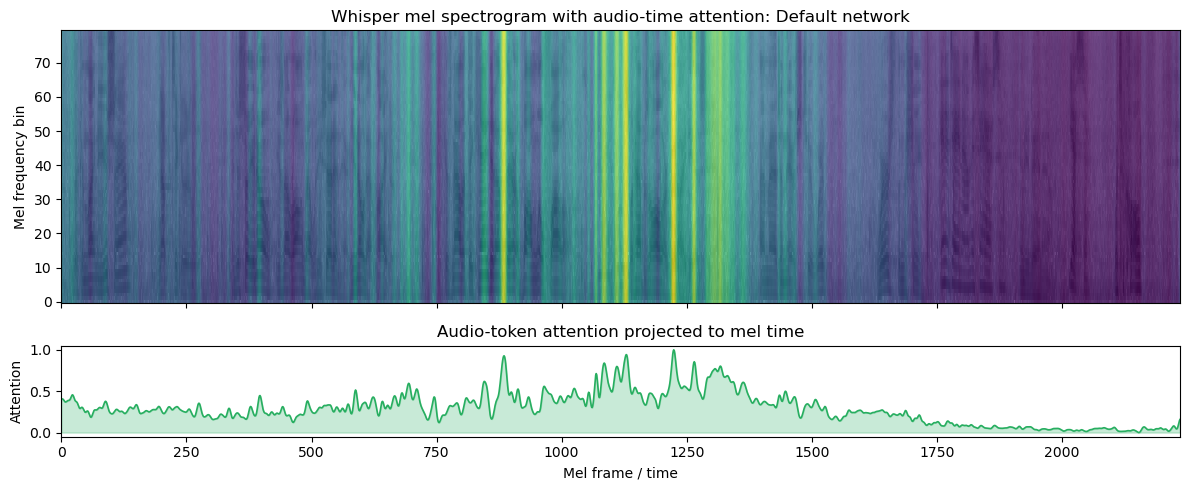

In [302]:
# Audio: project audio-token attention onto the Whisper mel-spectrogram time axis.
from scipy.ndimage import gaussian_filter1d

audio_token_attn = modality_attention["audio"]["token_attn"]
audio_query_label = modality_attention["audio"]["query_label"]
audio_start, audio_end = modality_specs["audio"]

mel = np.squeeze(to_np(audio["input_features"]))  # [mel bins, mel frames]
audio_attn = audio_token_attn[audio_start:audio_end]
audio_attn = audio_attn / (audio_attn.sum() + 1e-8)

frame_energy = mel.std(axis=0)
informative_frames = np.flatnonzero(frame_energy > np.percentile(frame_energy, 5))
last_frame = int(informative_frames[-1]) + 1
mel = mel[:, :last_frame]

mel_T = mel.shape[1]
tok_T = audio_attn.shape[0]
x_tok = np.linspace(0, mel_T - 1, tok_T)
x_mel = np.arange(mel_T)

att_mel = np.interp(x_mel, x_tok, audio_attn)
att_mel = att_mel / (att_mel.sum() + 1e-8)
att_mel = np.log1p(att_mel * 1e5)
att_mel = gaussian_filter1d(att_mel, sigma=3.0)
low, high = np.percentile(att_mel, [0, 100])
att_mel = np.clip(att_mel, low, high)
att_mel = (att_mel - low) / (high - low + 1e-8)
att_overlay = np.tile(att_mel[None, :], (mel.shape[0], 1))

print(f"mel.shape={mel.shape}, audio_attn.shape={audio_attn.shape}, att_mel.shape={att_mel.shape}, cropped_to_frame={last_frame}")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
axes[0].imshow(mel, aspect="auto", origin="lower", interpolation="nearest", cmap="gray_r")
axes[0].imshow(att_overlay, aspect="auto", origin="lower", interpolation="nearest", cmap=color_map, alpha=0.75)
axes[0].set_title(f"Whisper mel spectrogram with audio-time attention: {audio_query_label}")
axes[0].set_ylabel("Mel frequency bin")

axes[1].plot(x_mel, att_mel, color="#27AE60", linewidth=1.2)
axes[1].fill_between(x_mel, att_mel, color="#27AE60", alpha=0.25)
axes[1].set_title("Audio-token attention projected to mel time")
axes[1].set_xlabel("Mel frame / time")
axes[1].set_ylabel("Attention")
axes[1].set_xlim(0, mel_T - 1)

plt.tight_layout()
plt.show()



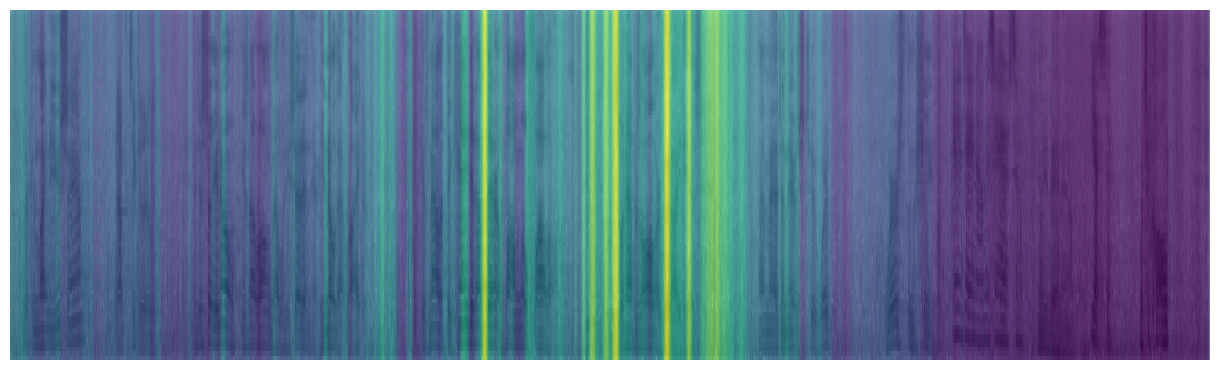

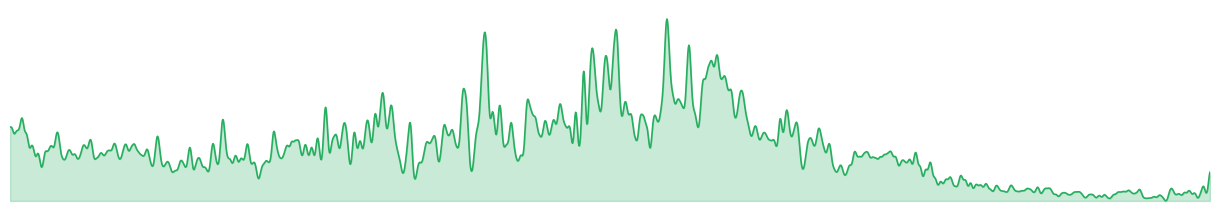

In [303]:

# Plot 1: Whisper mel spectrogram with audio-time attention overlay
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.imshow(mel, aspect="auto", origin="lower", interpolation="nearest", cmap="gray_r")
ax.imshow(att_overlay, aspect="auto", origin="lower", interpolation="nearest", cmap=color_map, alpha=0.75)
ax.set_axis_off()
ax.set_position([0, 0, 1, 1])  # <- stronger than subplots_adjust
plt.show()

fig.savefig(
    f"./notebooks/figures/attn/audio_{sample_id}_{modality_attention_config['audio']['network_name']}_mel.png",
    bbox_inches="tight",
    pad_inches=0,
    transparent=True
)
plt.close(fig)

# Plot 2: Audio-token attention projected to mel time
fig, ax = plt.subplots(figsize=(12, 2))
ax.plot(x_mel, att_mel, color="#27AE60", linewidth=1.2)
ax.fill_between(x_mel, att_mel, color="#27AE60", alpha=0.25)
ax.set_xlim(0, mel_T - 1)
ax.set_axis_off()
ax.set_position([0, 0, 1, 1])
plt.show()

fig.savefig(
    f"./notebooks/figures/attn/audio_{sample_id}_{modality_attention_config['audio']['network_name']}_dist.png",
    bbox_inches="tight",
    pad_inches=0,
    transparent=True
)

In [304]:
# Text: color valid tokenizer positions by attention and list top tokens.
text_token_attn = modality_attention["text"]["token_attn"]
text_query_label = modality_attention["text"]["query_label"]
text_start, text_end = modality_specs["text"]
text_attn = text_token_attn[text_start:text_end]
input_ids = to_np(text["input_ids"]).squeeze().astype(int).tolist()
attention_mask = to_np(text["attention_mask"]).squeeze().astype(bool).tolist()
valid_positions = np.flatnonzero(attention_mask)
valid_text_attn = text_attn[valid_positions]
valid_token_ids = [input_ids[pos] for pos in valid_positions]
valid_token_strings = np.asarray(tokenizer.convert_ids_to_tokens(valid_token_ids), dtype=object)
keep_tokens = valid_token_strings != "<|begin_of_text|>"
valid_positions = valid_positions[keep_tokens]
valid_text_attn = valid_text_attn[keep_tokens]
valid_text_norm = _normalize01(valid_text_attn)
valid_token_strings = valid_token_strings[keep_tokens].tolist()

def clean_text_token(tok, html=False):
    tok = tok.replace("Ġ", " ").replace("▁", " ")
    if html:
        tok = tok.replace(" ", "&nbsp;").replace("<", "&lt;").replace(">", "&gt;")
    return tok


html_parts = []
for tok, weight in zip(valid_token_strings, valid_text_norm):
    clean_tok = clean_text_token(tok, html=True)
    alpha = 0.1 + 0.9 * float(weight)
    html_parts.append(
        f'<span style="background: rgba(52, 168, 83, {alpha:.3f}); padding: 1px 2px; margin: 1px; border-radius: 2px; display: inline-block;">{clean_tok}</span>'
    ) # 235, 87, 87 # 244, 180, 0
display(HTML("<div style='line-height: 1.9; font-family: monospace;'>" + "".join(html_parts) + "</div>"))

from pathlib import Path

text_attention_html = (
    "<html><body>"
    "<div style='line-height: 1.9; font-family: Times New Roman ; font-size: 24px;'>"
    + "".join(html_parts)
    + "</div>"
    "</body></html>"
)

out_path = Path(f"./notebooks/figures/attn/text_attention_sample{sample_id}_{text_query_label.replace(' ', '_')}.html")
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(text_attention_html)
print(out_path)

notebooks/figures/attn/text_attention_sample368_Limbic_network.html
